In [4]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (24.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and direc

['NanumBarunGothic', 'NanumGothic', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumSquare', 'NanumSquareRound']


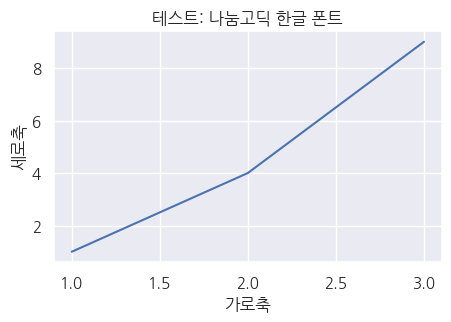

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 한글 폰트 확인 (NanumGothic, NanumBarunGothic 등 있을 수 있음)
print(sorted({f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name}))

# 대표 폰트로 NanumGothic (없으면 NanumBarunGothic 사용)
plt.rc('font', family='NanumGothic')     # 만약 없으면 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set(font='NanumGothic', rc={'axes.unicode_minus':False})

# 테스트
plt.figure(figsize=(5,3))
plt.title('테스트: 나눔고딕 한글 폰트')
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel('가로축')
plt.ylabel('세로축')
plt.show()


LinearRegression → RMSE: 73736, R²: 0.135, F1: 0.730


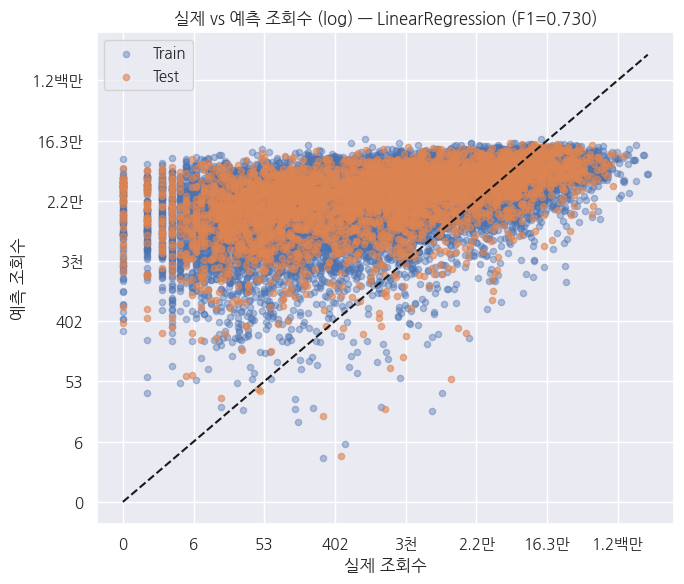

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 42
[LightGBM] [Info] Start training from score 25682.064508
LightGBM        → RMSE: 62195, R²: 0.384, F1: 0.679


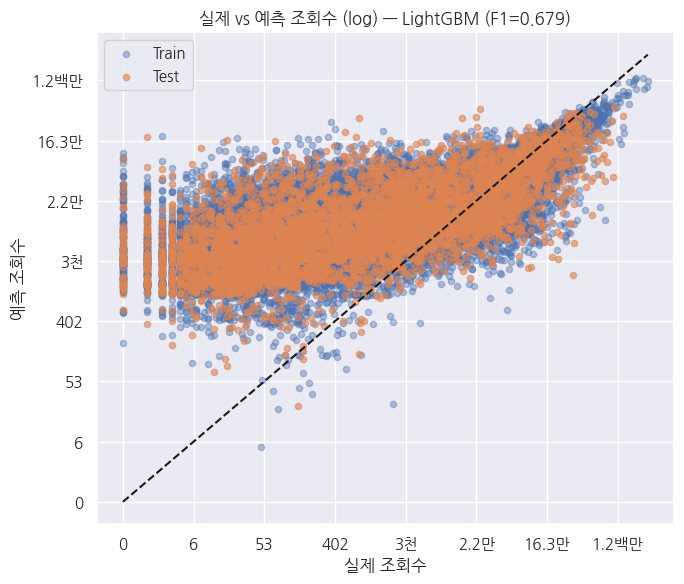

In [17]:
#1. 베이스라인 모델 결과 / 2. LightGBM 모델 결과
import os
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 0) 데이터 불러오기
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='UTF-8-SIG')

# 1) 전처리 함수
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

# 2) 피처/타깃 정의
feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일','시간대','주요_감정','URL_유무']

# 3) train/test split
data = df[feature_cols + [target_col]].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    data[feature_cols], data[target_col],
    test_size=0.2, random_state=42
)

# 4) 전처리 & 모델 준비
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

common_params = {
    'n_estimators': 262,
    'learning_rate': 0.012511752003328859,
    'max_depth': 12,
    'num_leaves': 94,
    'min_child_samples': 9,
    'subsample': 0.47024020985656356,
    'colsample_bytree': 0.6966521828215488,
    'random_state': 42
}

models = {
    'LinearRegression': Pipeline([
        ('prep', preprocessor),
        ('lr', LinearRegression())
    ]),
    'LightGBM': Pipeline([
        ('prep', preprocessor),
        ('lgbm', LGBMRegressor(**common_params))
    ]),
}

# 5) 시각화 함수
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    if true >= 1e4: return f"{true/1e4:.1f}만"
    if true >= 1e3: return f"{true/1e3:.0f}천"
    return f"{int(true)}"

def plot_compare(y_tr, y_tr_pred, y_te, y_te_pred, title, f1=None):
    plt.figure(figsize=(7,6))
    plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred),
                alpha=0.4, label='Train', s=20)
    plt.scatter(np.log1p(y_te), np.log1p(y_te_pred),
                alpha=0.6, label='Test', s=20)
    mn = min(np.log1p(y_tr.min()), np.log1p(y_te.min()))
    mx = max(np.log1p(y_tr.max()), np.log1p(y_te.max()))
    plt.plot([mn,mx],[mn,mx],'k--')
    title_full = f"{title} (F1={f1:.3f})" if f1 is not None else title
    plt.title(f'실제 vs 예측 조회수 (log) — {title_full}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    plt.legend(); plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.tight_layout()
    plt.show()

# 6) 학습·평가·그래프 + F1 스코어
threshold = np.median(y_train)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_tr_pred = pipe.predict(X_train)
    y_te_pred = pipe.predict(X_test)

    # 회귀 지표
    rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))
    r2   = r2_score(y_test, y_te_pred)

    # 이진 분류 & F1
    y_te_true_class = (y_test  >= threshold).astype(int)
    y_te_pred_class = (y_te_pred >= threshold).astype(int)
    f1 = f1_score(y_te_true_class, y_te_pred_class)

    print(f"{name:15s} → RMSE: {rmse:.0f}, R²: {r2:.3f}, F1: {f1:.3f}")
    plot_compare(y_train, y_tr_pred, y_test, y_te_pred, title=name, f1=f1)


In [18]:
#3. 하이퍼 파라미터 튜닝 및 선정 과정 & 목록
import os
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform

# --- 데이터 로드 & 전처리 (기존 코드와 동일) ---
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='UTF-8-SIG')

def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무'] = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

X = df[feature_cols].dropna()
y = df.loc[X.index, target_col]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 파이프라인 정의 ---
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(random_state=42))
])

# --- 하이퍼파라미터 탐색범위 정의 ---
param_distributions = {
    'lgbm__n_estimators': randint(100, 1500),
    'lgbm__learning_rate': uniform(0.001, 0.5),
    'lgbm__max_depth': randint(3, 15),
    'lgbm__num_leaves': randint(20, 200),
    'lgbm__min_child_samples': randint(5, 50),
    'lgbm__subsample': uniform(0.4, 0.6),
    'lgbm__colsample_bytree': uniform(0.4, 0.6),
}

# --- RandomizedSearchCV 설정 & 학습 ---
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=300,              # 시도할 파라미터 조합 수
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best RMSE:", -search.best_score_)
print("Best Params:", search.best_params_)

# --- 최적 모델로 평가 (수정) ---
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

# squared=False 대신 직접 sqrt 사용
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Test set RMSE: {rmse:.0f}, R²: {r2:.3f}")


Fitting 3 folds for each of 300 candidates, totalling 900 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 42
[LightGBM] [Info] Start training from score 25682.064508
Best RMSE: 82896.27584191615
Best Params: {'lgbm__colsample_bytree': np.float64(0.5935167867078491), 'lgbm__learning_rate': np.float64(0.012446912488060125), 'lgbm__max_depth': 13, 'lgbm__min_child_samples': 6, 'lgbm__n_estimators': 1030, 'lgbm__num_leaves': 39, 'lgbm__subsample': np.float64(0.7438248573585096)}
Test set RMSE: 62563, R²: 0.377


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006948 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 42
[LightGBM] [Info] Start training from score 25682.064508
회귀 결과 → RMSE: 62563, R²: 0.377
이진 분류 F1 스코어 (threshold=565): 0.736


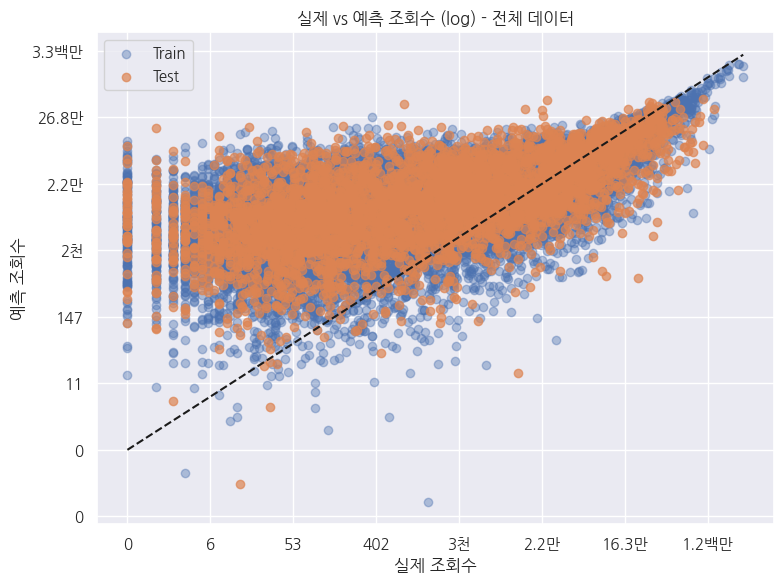

In [20]:
# 4. LightGBM 튜닝 결과 반영
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.ticker as ticker

# 0) 파일 로드
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='UTF-8-SIG')

# 1) 전처리
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

# 2) train/test split
full = df[feature_cols + [target_col]].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    full[feature_cols], full[target_col],
    test_size=0.2, random_state=42
)

# 3) 파이프라인 + 최적 하이퍼파라미터 적용
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=1030,
        learning_rate=0.012446912488060125,
        max_depth=13,
        num_leaves=39,
        min_child_samples=6,
        subsample=0.7438248573585096,
        colsample_bytree=0.5935167867078491,
        random_state=42
    ))
])

# 4) 학습 & 예측
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 5) 회귀 지표
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
print(f"회귀 결과 → RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 6) 이진 분류 레이블 생성 (기준: y_train 중앙값)
threshold = np.median(y_train)
y_true_class = (y_test  >= threshold).astype(int)
y_pred_class = (y_test_pred >= threshold).astype(int)

# 7) F1 스코어 계산
f1 = f1_score(y_true_class, y_pred_class)
print(f"이진 분류 F1 스코어 (threshold={int(threshold)}): {f1:.3f}")

# 8) 시각화 함수 & 그래프
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    if true >= 1e4: return f"{true/1e4:.1f}만"
    if true >= 1e3: return f"{true/1e3:.0f}천"
    return f"{int(true)}"

def plot_compare(y_tr, y_tr_pred, y_te, y_te_pred, title_tag):
    plt.figure(figsize=(8,6))
    plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred), alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_te), np.log1p(y_te_pred), alpha=0.7, label='Test')
    mn = min(np.log1p(y_tr).min(), np.log1p(y_te).min())
    mx = max(np.log1p(y_tr).max(), np.log1p(y_te).max())
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plot_compare(y_train, y_train_pred, y_test, y_test_pred, title_tag="전체 데이터")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 42
[LightGBM] [Info] Start training from score 25682.064508
회귀 결과 → RMSE: 62563, R²: 0.377
이진 분류 F1 스코어 (threshold=565): 0.736


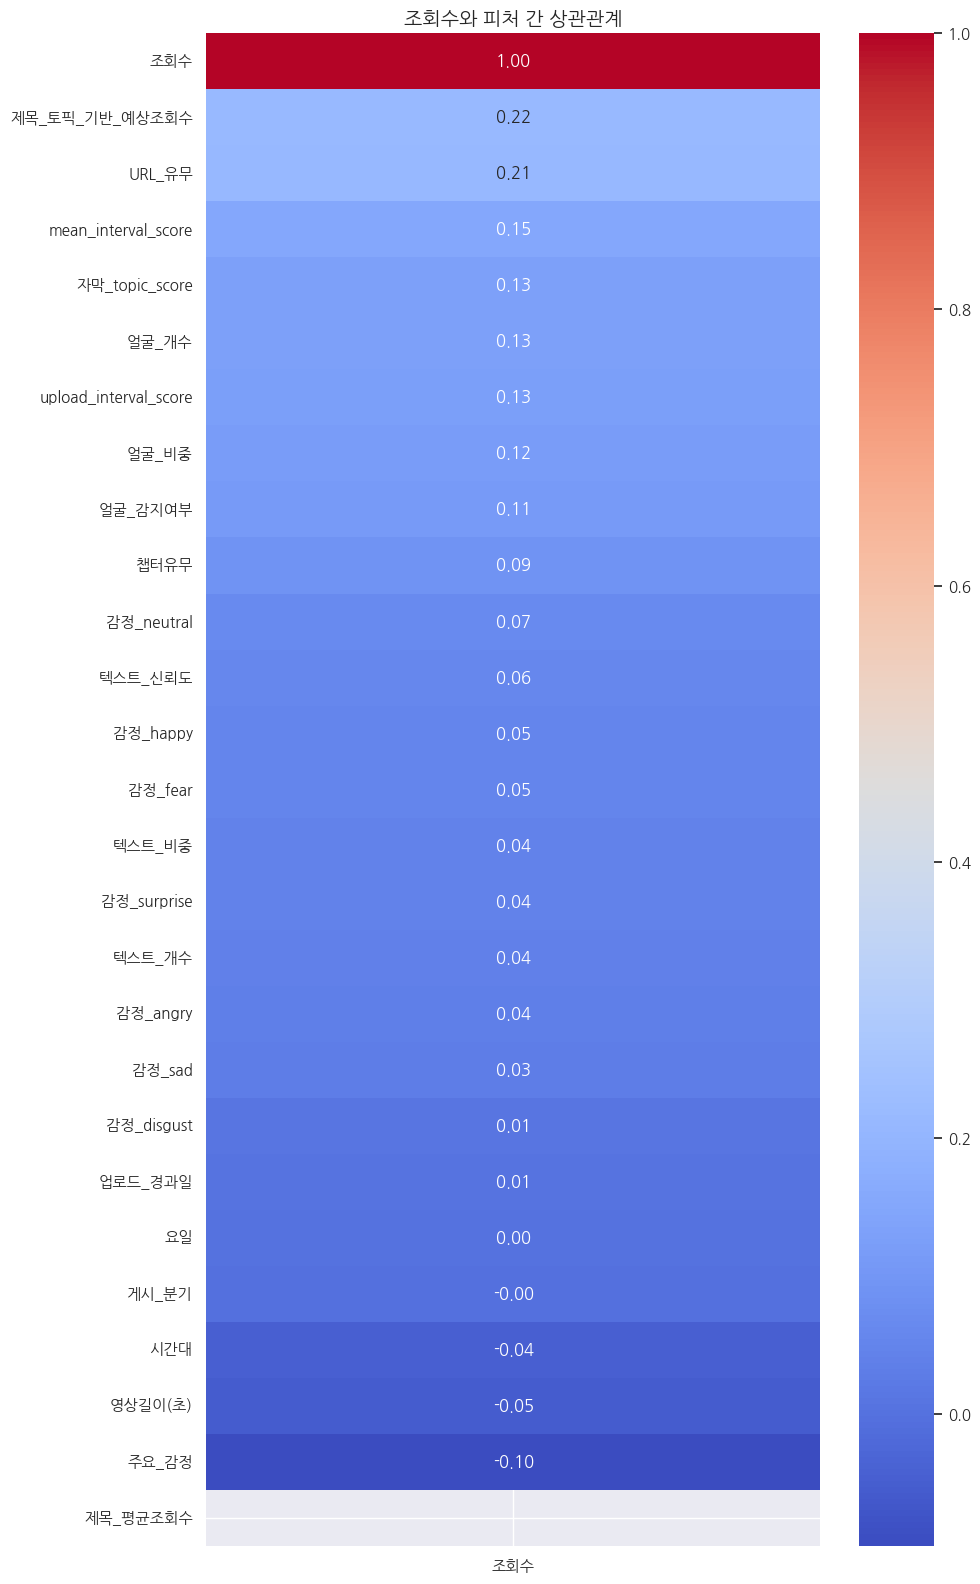

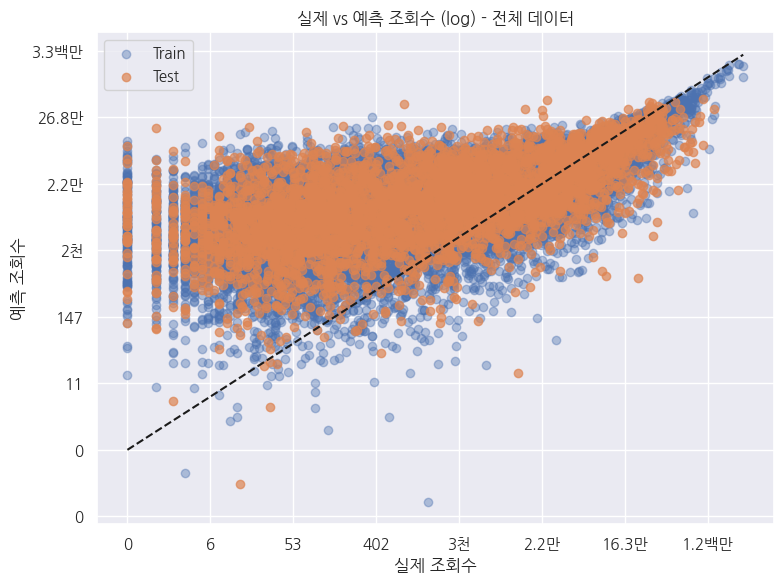

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.ticker as ticker
import seaborn as sns

# 0) 파일 로드
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='UTF-8-SIG')

# 1) 전처리: 시간대 분류, 얼굴/URL 이진화
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

# 2) 피처·타깃 정의
feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']


# 2) train/test split
full = df[feature_cols + [target_col]].dropna()
X = full[feature_cols]
y = full[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) 파이프라인 + 최적 하이퍼파라미터 적용
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=1030,
        learning_rate=0.012446912488060125,
        max_depth=13,
        num_leaves=39,
        min_child_samples=6,
        subsample=0.7438248573585096,
        colsample_bytree=0.5935167867078491,
        random_state=42
    ))
])

# 4) 학습 & 예측
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 5) 회귀 지표 (squared 인자 제거 후 np.sqrt 사용)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
print(f"회귀 결과 → RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 6) 이진 분류 레이블 생성 (기준: y_train 중앙값)
threshold = np.median(y_train)
y_true_class = (y_test  >= threshold).astype(int)
y_pred_class = (y_test_pred >= threshold).astype(int)

# 7) F1 스코어 계산
f1 = f1_score(y_true_class, y_pred_class)
print(f"이진 분류 F1 스코어 (threshold={int(threshold)}): {f1:.3f}")

# 8) 시각화 함수
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    if true >= 1e4: return f"{true/1e4:.1f}만"
    if true >= 1e3: return f"{true/1e3:.0f}천"
    return f"{int(true)}"

def plot_compare(y_tr, y_tr_pred, y_te, y_te_pred, title_tag):
    plt.figure(figsize=(8,6))
    plt.scatter(np.log1p(y_tr), np.log1p(y_tr_pred), alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_te), np.log1p(y_te_pred), alpha=0.7, label='Test')
    mn = min(np.log1p(y_tr).min(), np.log1p(y_te).min())
    mx = max(np.log1p(y_tr).max(), np.log1p(y_te).max())
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.legend(), plt.grid(True); plt.tight_layout(); plt.show()

# 9) 상관관계 시각화 (범주형 변수는 숫자형으로 변환 필요)
df_corr = full.copy()

# Label Encoding → 범주형 변수들
from sklearn.preprocessing import LabelEncoder
for col in categorical_features:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# 상관계수 계산 및 히트맵
corr_matrix = df_corr[feature_cols + [target_col]].corr()

plt.figure(figsize=(10, 16))
sns.heatmap(corr_matrix[[target_col]].sort_values(by=target_col, ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("조회수와 피처 간 상관관계", fontsize=14)
plt.tight_layout()
plt.show()

plot_compare(y_train, y_train_pred, y_test, y_test_pred, title_tag="전체 데이터")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 42
[LightGBM] [Info] Start training from score 25682.064508
회귀 결과 → RMSE: 62563, R²: 0.377
이진 분류 F1 스코어 (threshold=565): 0.736


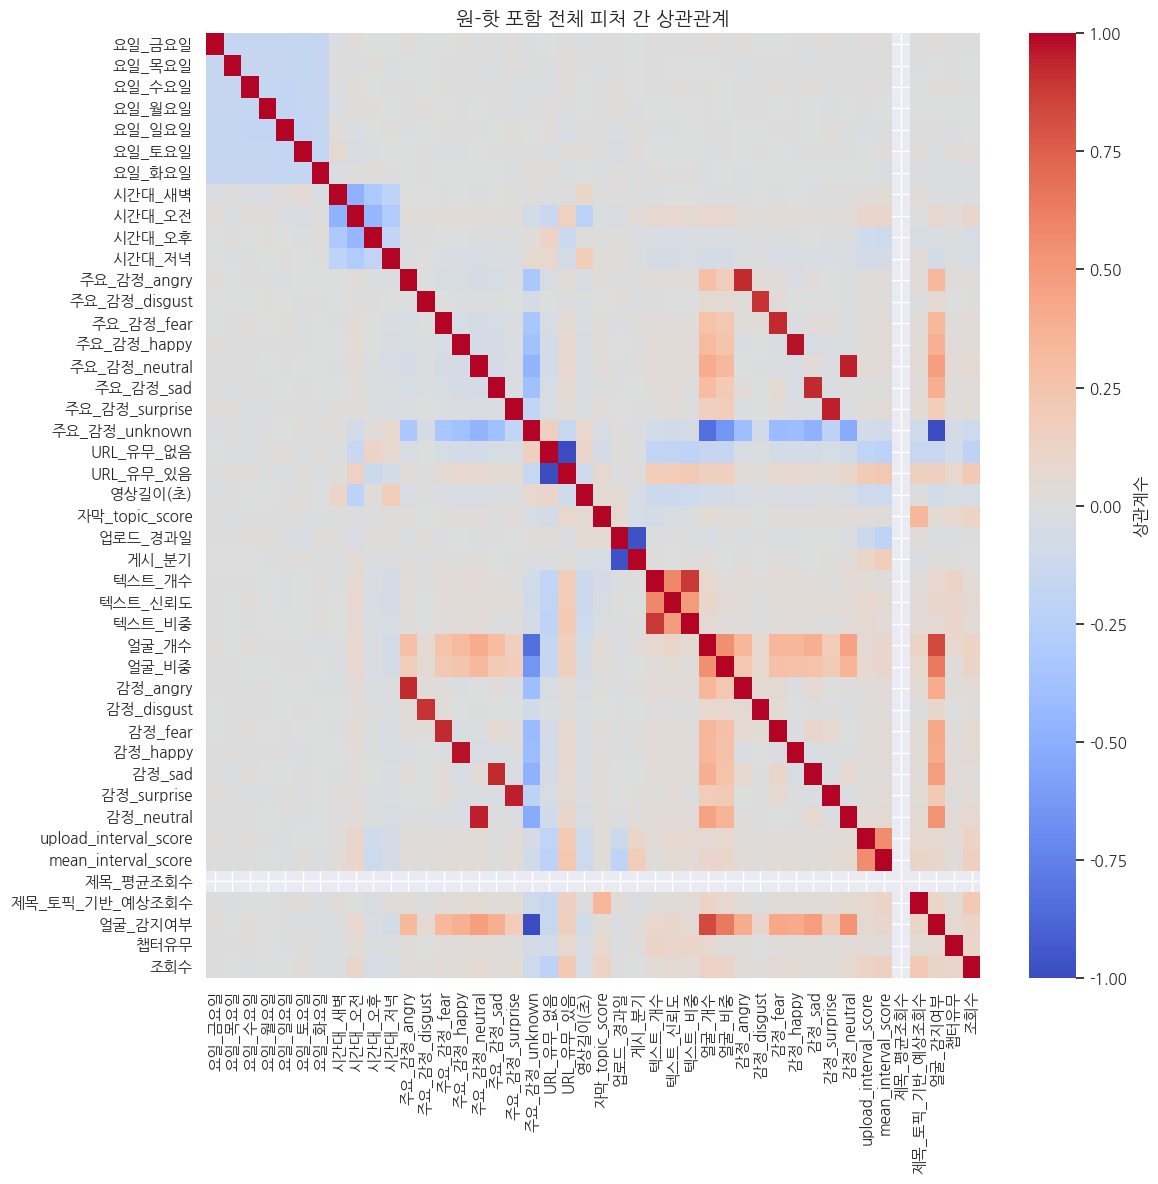

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import matplotlib.ticker as ticker

# 0) 파일 로드
file_path = 'final_data_챕터유무추가.csv'
df = pd.read_csv(file_path, encoding='UTF-8-SIG')

# 1) 전처리: 시간대 분류, 얼굴/URL 이진화
def categorize_hour(hour):
    try:
        h = int(hour)
        if   6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else:              return '새벽'
    except:
        return np.nan

df['시간대']       = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무']     = df['URL_유무'].map({True:'있음', False:'없음'})

# 2) 피처·타깃 정의
feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

# 3) 학습/테스트 분할
data = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
X = data[feature_cols]
y = data[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) 전처리기 & 모델 파이프라인 (튜닝 파라미터 적용)
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

tuned_params = {
    'n_estimators': 1030,
    'learning_rate': 0.012446912488060125,
    'max_depth': 13,
    'num_leaves': 39,
    'min_child_samples': 6,
    'subsample': 0.7438248573585096,
    'colsample_bytree': 0.5935167867078491,
    'random_state': 42
}

model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(**tuned_params))
])

# 5) 학습 & 예측
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 6) 회귀 성능 지표
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
print(f"회귀 결과 → RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 7) 간단 이진 분류 F1 스코어
threshold      = np.median(y_train)
y_true_class   = (y_test >= threshold).astype(int)
y_pred_class   = (y_test_pred >= threshold).astype(int)
f1             = f1_score(y_true_class, y_pred_class)
print(f"이진 분류 F1 스코어 (threshold={int(threshold)}): {f1:.3f}")

# 9) 상관관계 시각화 (원-핫 포함 전체 피처)
from sklearn.preprocessing import OneHotEncoder

# (1) 원-핫 인코딩
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
dummies = ohe.fit_transform(full[categorical_features])
dummy_cols = ohe.get_feature_names_out(categorical_features)

# (2) 더미 DF + 수치형 DF + 타깃 결합
df_dummies = pd.DataFrame(dummies, columns=dummy_cols, index=full.index)
df_numeric = full.drop(columns=categorical_features + [target_col])
encoded_df = pd.concat([df_dummies, df_numeric, full[[target_col]]], axis=1)

# (3) 상관계수 계산
corr_matrix = encoded_df.corr()

# (4) 히트맵 그리기
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={'label': '상관계수'}
)
plt.title("원-핫 포함 전체 피처 간 상관관계", fontsize=14)
plt.tight_layout()
plt.show()


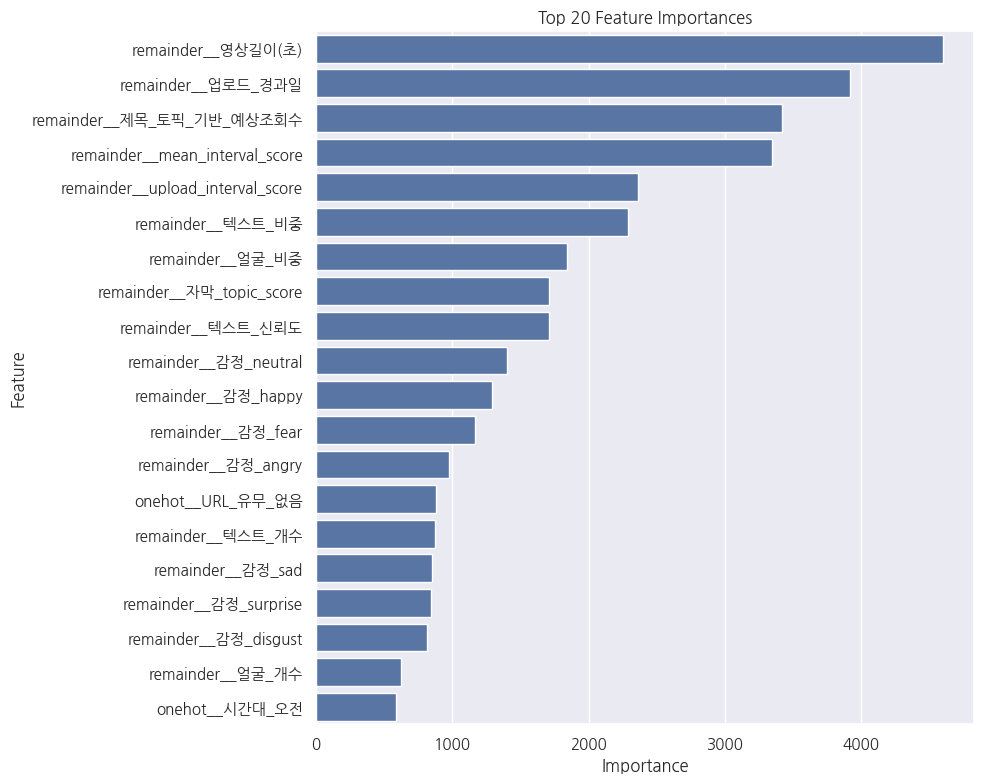

In [28]:
# 9) 피처 중요도 시각화
import seaborn as sns

# (1) 전처리된 피처 이름 얻기
#    ColumnTransformer + OneHotEncoder를 쓴 경우 get_feature_names_out() 호출
feature_names = model.named_steps['prep'].get_feature_names_out()

# (2) LightGBM에서 중요도 뽑기
importances = model.named_steps['lgbm'].feature_importances_

# (3) Series로 정리하고 내림차순 정렬
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# (4) 상위 20개 피처 그리기
plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
